In [2]:
import matplotlib.pyplot as plt 
import pandas as pd
import numpy as np
from matplotlib.backends.backend_pdf import PdfPages


In [3]:
data = pd.read_csv('data/intresting_data_to_visualize/cancer_b.csv',header=0)
numdata = data.select_dtypes(include=['int64','float64'])
numdata = numdata.iloc[:,1:]
numdata

,Radius (mean),Texture (mean),Perimeter (mean),Area (mean),Smoothness (mean),Compactness (mean),Concavity (mean),Concave points (mean),Symmetry (mean),Fractal dimension (mean),...,Radius (worst),Texture (worst),Perimeter (worst),Area (worst),Smoothness (worst),Compactness (worst),Concavity (worst),Concave points (worst),Symmetry (worst),Fractal dimension (worst)
0,13.540,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.047810,0.1885,0.05766,...,15.110,19.26,99.70,711.2,0.14400,0.17730,0.23900,0.12880,0.2977,0.07259
1,13.080,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.031100,0.1967,0.06811,...,14.500,20.49,96.09,630.5,0.13120,0.27760,0.18900,0.07283,0.3184,0.08183
2,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.020760,0.1815,0.06905,...,10.230,15.66,65.13,314.9,0.13240,0.11480,0.08867,0.06227,0.2450,0.07773
3,13.030,18.42,82.61,523.8,0.08983,0.03766,0.02562,0.029230,0.1467,0.05863,...,13.300,22.81,84.46,545.9,0.09701,0.04619,0.04833,0.05013,0.1987,0.06169
4,8.196,16.84,51.71,201.9,0.08600,0.05943,0.01588,0.005917,0.1769,0.06503,...,8.964,21.96,57.26,242.2,0.12970,0.13570,0.06880,0.02564,0.3105,0.07409
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
352,14.590,22.68,96.39,657.1,0.08473,0.13300,0.10290,0.037360,0.1454,0.06147,...,15.480,27.27,105.90,733.5,0.10260,0.31710,0.36620,0.11050,0.2258,0.08004
353,11.510,23.93,74.52,403.5,0.09261,0.10210,0.11120,0.041050,0.1388,0.06570,...,12.480,37.16,82.28,474.2,0.12980,0.25170,0.36300,0.09653,0.2112,0.08732
354,14.050,27.15,91.38,600.4,0.09929,0.11260,0.04462,0.043040,0.1537,0.06171,...,15.300,33.17,100.20,706.7,0.12410,0.22640,0.13260,0.10480,0.2250,0.08321
355,11.200,29.37,70.67,386.0,0.07449,0.03558,0.00000,0.000000,0.1060,0.05502,...,11.920,38.30,75.19,439.6,0.09267,0.05494,0.00000,0.00000,0.1566,0.05905


subgraph1.pdf
Histogram of Bin 1
Bin 1: 6.981 - 7.0588999999999995
1
Bin 2: 7.0588999999999995 - 7.136799999999999
0
Bin 3: 7.1368 - 7.2147
0
Bin 4: 7.2147 - 7.292599999999999
0
Bin 5: 7.2926 - 7.3705
0
Bin 6: 7.3705 - 7.4483999999999995
0
Bin 7: 7.4483999999999995 - 7.526299999999999
0
Bin 8: 7.5263 - 7.6042
0
Bin 9: 7.6042 - 7.682099999999999
0
Bin 10: 7.6821 - 7.76
3
Histogram of Bin 2
Bin 1: 8.196 - 8.2806
2
Bin 2: 8.2806 - 8.3652
0
Bin 3: 8.3652 - 8.4498
0
Bin 4: 8.4498 - 8.5344
0
Bin 5: 8.5344 - 8.619
4
Bin 6: 8.619 - 8.7036
1
Bin 7: 8.7036 - 8.7882
2
Bin 8: 8.7882 - 8.8728
0
Bin 9: 8.8728 - 8.9574
3
Bin 10: 8.9574 - 9.042
3
Histogram of Bin 3
Bin 1: 9.173 - 9.2807
2
Bin 2: 9.2807 - 9.388399999999999
2
Bin 3: 9.3884 - 9.4961
5
Bin 4: 9.4961 - 9.6038
2
Bin 5: 9.6038 - 9.7115
5
Bin 6: 9.711500000000001 - 9.8192
8
Bin 7: 9.8192 - 9.9269
4
Bin 8: 9.9269 - 10.0346
1
Bin 9: 10.0346 - 10.142299999999999
2
Bin 10: 10.1423 - 10.25
5
Histogram of Bin 4
Bin 1: 10.25 - 10.359
6
Bin 2: 10.359

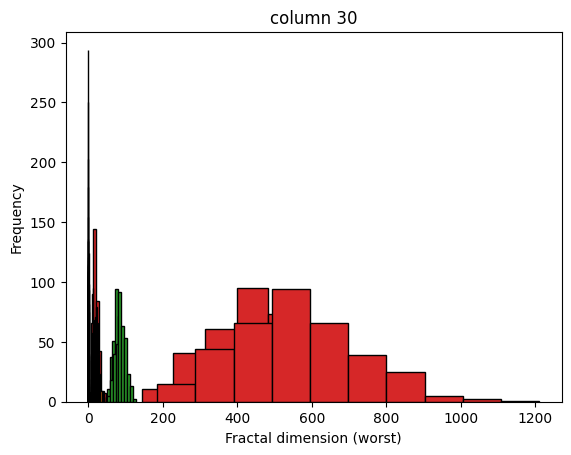

In [4]:
bins=10
with PdfPages("./cancerGraphs/cancerColumens.pdf") as pdf:
    for i in range(len(numdata.columns)):
        plt.title(f'column {i+1}')
        plt.hist(numdata.iloc[:,i].values,bins=10,edgecolor='black')
        plt.ylabel('Frequency')
        plt.xlabel(numdata.columns[i])
        # pdf.savefig()
        # plt.close()
        current_columen = numdata.iloc[:,i].values
        max_value = current_columen.max()
        min_value = current_columen.min()
        start = min_value
        binrange = round((max_value - min_value) / bins, 2)
        # print(min_value)
        # print(max_value)
        # print(binrange)

        with PdfPages(f"./cancerGraphs/subgraph{i+1}.pdf") as pdfbin:
            print(f'subgraph{i+1}.pdf')
            for j in range(bins):
                    offset = round(start + binrange, 2)

                    new_numdata = current_columen[(current_columen >= start) & (current_columen<= offset)]
                    # plt.hist(new_numdata, bins=10, edgecolor='black')
                    # plt.title(f"Histogram of Bin {j+1}")
                    # plt.xlabel(f'{numdata.columns[i]} (range {start}-{offset})')
                    # plt.ylabel('frequency')

                    print(f"Histogram of Bin {j+1}")
                    interpret_data = np.array(new_numdata)
                    if len(interpret_data) > 0:
                        min_interpret = interpret_data.min()
                        max_interpret = interpret_data.max()
                        bin_width = (max_interpret - min_interpret) / bins

                        for k in range(bins):
                            start_range = min_interpret + bin_width * k
                            end_range = start_range + bin_width
                            # For the last bin, ensure it includes the maximum value
                            if k == bins - 1:
                                end_range = max_interpret
                            print(f"Bin {k+1}: {start_range} - {end_range}")

                            bin_data = interpret_data[(interpret_data >= start_range) & (interpret_data<= end_range)]
                            print(len(bin_data))

                        # new_df = pd.DataFrame(temp_df)
                        # print(new_df)
                    # pdfbin.savefig()
                    # plt.close()
        
                    start = round(start + binrange, 2)
            # print(f'saved {i+1}')

subgraph1.pdf
Histogram of Bin 1
Bin 1: 6.9810 - 7.0589 -> 25.00%
Bin 10: 7.6821 - 7.7600 -> 75.00%
Histogram of Bin 2
Bin 1: 8.1960 - 8.2806 -> 13.33%
Bin 5: 8.5344 - 8.6190 -> 26.67%
Bin 6: 8.6190 - 8.7036 -> 6.67%
Bin 7: 8.7036 - 8.7882 -> 13.33%
Bin 9: 8.8728 - 8.9574 -> 20.00%
Bin 10: 8.9574 - 9.0420 -> 20.00%
Histogram of Bin 3
Bin 1: 9.1730 - 9.2807 -> 5.56%
Bin 2: 9.2807 - 9.3884 -> 5.56%
Bin 3: 9.3884 - 9.4961 -> 13.89%
Bin 4: 9.4961 - 9.6038 -> 5.56%
Bin 5: 9.6038 - 9.7115 -> 13.89%
Bin 6: 9.7115 - 9.8192 -> 22.22%
Bin 7: 9.8192 - 9.9269 -> 11.11%
Bin 8: 9.9269 - 10.0346 -> 2.78%
Bin 9: 10.0346 - 10.1423 -> 5.56%
Bin 10: 10.1423 - 10.2500 -> 13.89%
Histogram of Bin 4
Bin 1: 10.2500 - 10.3590 -> 10.53%
Bin 2: 10.3590 - 10.4680 -> 1.75%
Bin 3: 10.4680 - 10.5770 -> 14.04%
Bin 4: 10.5770 - 10.6860 -> 5.26%
Bin 5: 10.6860 - 10.7950 -> 3.51%
Bin 6: 10.7950 - 10.9040 -> 10.53%
Bin 7: 10.9040 - 11.0130 -> 7.02%
Bin 8: 11.0130 - 11.1220 -> 10.53%
Bin 9: 11.1220 - 11.2310 -> 14.04%
Bin

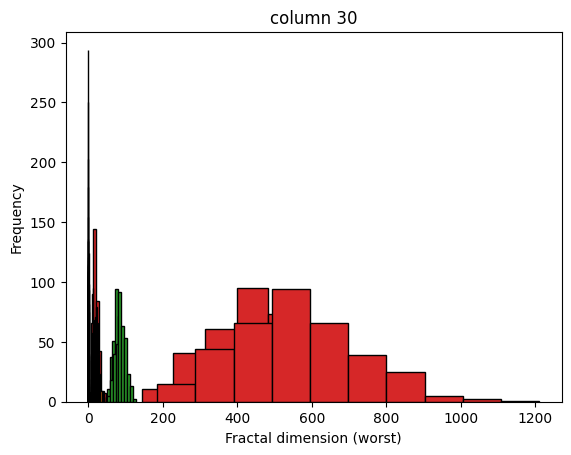

In [9]:
bins = 10
with PdfPages("./cancerGraphs/cancerColumens.pdf") as pdf:
    for i in range(len(numdata.columns)):
        plt.title(f'column {i+1}')
        plt.hist(numdata.iloc[:, i].values, bins=10, edgecolor='black')
        plt.ylabel('Frequency')
        plt.xlabel(numdata.columns[i])

        current_column = numdata.iloc[:, i].values
        max_value = current_column.max()
        min_value = current_column.min()
        total_count = len(current_column)   
        start = min_value
        binrange = round((max_value - min_value) / bins, 2)

        with PdfPages(f"./cancerGraphs/subgraph{i+1}.pdf") as pdfbin:
            print(f'subgraph{i+1}.pdf')
            for j in range(bins):
                offset = round(start + binrange, 2)
                new_numdata = current_column[(current_column >= start) & (current_column <= offset)]

                print(f"Histogram of Bin {j+1}")
                interpret_data = np.array(new_numdata)
                if len(interpret_data) > 0:
                    min_interpret = interpret_data.min()
                    max_interpret = interpret_data.max()
                    bin_width = (max_interpret - min_interpret) / bins

                    for k in range(bins):
                        start_range = min_interpret + bin_width * k
                        end_range = start_range + bin_width
                        if k == bins - 1:
                            end_range = max_interpret

                        bin_data = interpret_data[(interpret_data >= start_range) & (interpret_data <= end_range)]
                        count = len(bin_data)

                        if total_count > 0:
                            percent = (count / len(new_numdata)) * 100
                        else:
                            percent = 0

                        if percent > 0:
                            print(f"Bin {k+1}: {start_range:.4f} - {end_range:.4f} -> {percent:.2f}%")


                start = round(start + binrange, 2)
